# EquiAlgo Challenge - baseline model

**Engineering & Computer Science Hackathon 2026 - 24-hour challenge**

This notebook loads the data, trains the model currently in production at
our financial partner, measures its performance, and runs a first fairness audit.

It doesn't fix anything. That's your job.

Run it end to end once (Cell > Run All), read section 5, then start from there.

---


## 1. Loading the data

Two files:

| File | Rows | Contains |
|---|---|---|
| `data/donnees_demandes.csv` | 10,000 | historical applications **with** `decision_octroi` |
| `data/candidats_evaluation.csv` | 4,000 | new applications, **without** a label - these are the ones you'll be scored on |


In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    selection_rate,
    true_positive_rate,
)

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

print(f'{len(demandes)} historical applications, {len(candidats)} to evaluate')
demandes.head()


10000 historical applications, 4000 to evaluate


,id_candidat,cote_r_equivalent,programme_etudes,region_administrative,code_postal_3,revenu_familial_estime,heures_travail_semaine,distance_domicile_campus_km,premiere_generation_universitaire,decision_octroi
0,C008033,25.96,Genie,Cote-Nord,G4R,17017,9,168.0,0,0
1,C004299,26.82,Arts et lettres,Cote-Nord,G5B,66820,22,99.3,0,0
2,C011788,27.37,Genie,Bas-Saint-Laurent,G5N,49223,19,364.1,0,0
3,C001144,21.23,Sciences,Gaspesie-Iles-de-la-Madeleine,G5C,90750,17,174.8,1,0
4,C003322,28.27,Sante,Bas-Saint-Laurent,G5N,36892,9,151.2,0,0


In [9]:
demandes.info()
print()
print(demandes.describe(include='all').T[['count', 'unique', 'top', 'mean']])


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_candidat                        10000 non-null  str    
 1   cote_r_equivalent                  10000 non-null  float64
 2   programme_etudes                   10000 non-null  str    
 3   region_administrative              10000 non-null  str    
 4   code_postal_3                      10000 non-null  str    
 5   revenu_familial_estime             10000 non-null  int64  
 6   heures_travail_semaine             10000 non-null  int64  
 7   distance_domicile_campus_km        10000 non-null  float64
 8   premiere_generation_universitaire  10000 non-null  int64  
 9   decision_octroi                    10000 non-null  int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 781.4 KB

                                     count unique       top        mean
id

## 2. A first look at the regions

The committee awarded a scholarship to 40% of applicants. Is that rate the same everywhere?


In [10]:
# The five administrative regions present in the dataset.
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

def groupe_region(df):
    """Groups the five regions into two blocks: major centres / remote regions."""
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

par_region = demandes.groupby('region_administrative').agg(
    applicants=('decision_octroi', 'size'),
    award_rate=('decision_octroi', 'mean'),
    mean_cote_r=('cote_r_equivalent', 'mean'),
).sort_values('award_rate')
print(par_region.round(3))

demandes['groupe'] = groupe_region(demandes)
print()
print(demandes.groupby('groupe')['decision_octroi'].mean().round(3))


                               applicants  award_rate  mean_cote_r
region_administrative                                             
Cote-Nord                            1178       0.263       27.325
Bas-Saint-Laurent                    1293       0.269       27.296
Gaspesie-Iles-de-la-Madeleine        1529       0.284       27.354
Montreal                             4001       0.483       27.988
Capitale-Nationale                   1999       0.484       27.984

groupe
Centre      0.484
Eloignee    0.273
Name: decision_octroi, dtype: float64


Note the R-score (cote R) gap between regions, then the gap in award rates.
Is the second entirely explained by the first? Keep the question open.


## 3. The production model

A random forest trained on all available columns, including
`region_administrative`. This is the model the institution uses today.


In [11]:
CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']

def encoder(df_entrainement, df_cible):
    """Encodes the categorical columns and aligns the columns of the two tables.

    The alignment (reindex) matters: if a category is missing from one of the
    two sets, get_dummies produces a different number of columns and the model
    fails - or worse, learns on the wrong columns.
    """
    X = pd.get_dummies(
        df_entrainement.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    )
    Xc = pd.get_dummies(
        df_cible.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    ).reindex(columns=X.columns, fill_value=0)
    return X, Xc

# Internal split to measure performance honestly.
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
X_train, X_test = encoder(train, test)
y_train, y_test = train['decision_octroi'], test['decision_octroi']

modele = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

print(f'Overall accuracy: {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, digits=3))


Overall accuracy: 88.13%

              precision    recall  f1-score   support

           0      0.890     0.916     0.903      1802
           1      0.867     0.830     0.848      1198

    accuracy                          0.881      3000
   macro avg      0.879     0.873     0.875      3000
weighted avg      0.881     0.881     0.881      3000



About 88% accuracy. From the quarterly dashboard's point of view, the model is doing very well.


## 4. Fairness audit

Two measures, and they don't say the same thing:

- **Demographic parity** - do both groups receive scholarships at the same rate?
- **Equal opportunity** - among applicants who deserve the scholarship, do both
  groups have the same chance of getting it?

The second requires knowing who deserves the scholarship. Look closely at what it's computed with here.


In [12]:
groupe_test = groupe_region(test)

cadre = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'true_positive_rate': true_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=groupe_test,
)
print(cadre.by_group.round(4))

ecart_parite = demographic_parity_difference(y_test, y_pred, sensitive_features=groupe_test)
print(f'\nDemographic parity difference: {ecart_parite:.4f}')


                     accuracy  selection_rate  true_positive_rate
sensitive_feature_0                                              
Centre                 0.8777          0.4586              0.8475
Eloignee               0.8865          0.2710              0.7847

Demographic parity difference: 0.1876


The `true_positive_rate` above is computed against `decision_octroi`,
that is, against the committee's past decisions.

In other words: we just checked that the model faithfully reproduces the committee.
That's not the same as checking that it is fair.


## 5. The trap

The reflex is to drop `region_administrative` and declare the problem solved.
Let's measure.


In [13]:
essais = {'full model': []}

def entrainer_sans(colonnes_exclues, etiquette):
    X, Xt = encoder(train, test)
    garder = [c for c in X.columns if not c.startswith(tuple(colonnes_exclues))] if colonnes_exclues else list(X.columns)
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
    m.fit(X[garder], y_train)
    p = m.predict(Xt[garder])
    ecart = demographic_parity_difference(y_test, p, sensitive_features=groupe_test)
    print(f'{etiquette:<42} accuracy {accuracy_score(y_test, p):.4f}   parity gap {ecart:.4f}')
    return ecart

entrainer_sans((), 'all columns')
entrainer_sans(('region_administrative_',), 'without region_administrative')
entrainer_sans(('region_administrative_', 'code_postal_3_'), 'without region or postal code')


all columns                                accuracy 0.8813   parity gap 0.1876
without region_administrative              accuracy 0.8837   parity gap 0.1805
without region or postal code              accuracy 0.8797   parity gap 0.1737


np.float64(0.1736705949985628)

The gap barely moves.

Other columns carry the regional information: home-to-campus distance, hours
worked, family income, postal code. Removing the label doesn't remove the
signal. This is the **proxy effect**.

Measure it yourself - a correlation matrix, or a model that tries to predict the
region from the other columns, will tell you which ones leak the most.


## 6. Your mission

Produce, for the 4,000 applicants in `data/candidats_evaluation.csv`, an award
decision that is fairer than the current model's.

Three constraints:

1. **Fixed budget.** The institution funds a fixed number of scholarships. Your overall
   award rate must stay between **36% and 44%**. A submission outside this range gets 0
   on the technical section. Awarding the scholarship to everyone is not a solution.
2. **You are not scored on `decision_octroi`.** The jury compares your decisions to a
   reference standard built independently of the historical committee, which you don't have.
   Perfectly reproducing `decision_octroi` perfectly reproduces the bias.
3. **Format.** Two columns, 4,000 rows, values 0 or 1.

The next cell writes a valid submission from the biased model. It serves as a
template. Replace `predictions` with your own.


In [7]:
X_hist, X_cand = encoder(demandes, candidats)
modele_complet = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
modele_complet.fit(X_hist, demandes['decision_octroi'])
predictions = modele_complet.predict(X_cand)

soumission = pd.DataFrame({
    'id_candidat': candidats['id_candidat'],
    'decision_octroi': predictions.astype(int),
})
soumission.to_csv('predictions.csv', index=False)

taux = soumission['decision_octroi'].mean()
print(f'{len(soumission)} rows written to predictions.csv')
print(f'Award rate: {taux:.1%}', '- OK' if 0.36 <= taux <= 0.44 else '- OUT OF BUDGET')
soumission.head()


4000 rows written to predictions.csv
Award rate: 39.1% - OK


,id_candidat,decision_octroi
0,C011476,0
1,C000471,0
2,C006911,0
3,C007718,0
4,C003531,0


---

### Next steps

- Which columns best predict the region? Those are your proxies.
- Between demographic parity and equal opportunity, which would you defend before an
  ethics committee, and why? The two can't both be satisfied at once unless the two
  groups have exactly the same profile.
- `fairlearn.postprocessing.ThresholdOptimizer` and `fairlearn.reductions.ExponentiatedGradient`
  are the two quickest tools to set up. The first adjusts thresholds after the fact,
  the second retrains under a constraint.
- Vary the fairness constraint and plot the (fairness, accuracy) scatter: that's your
  Pareto front, and the jury will ask you to defend it.
- If `decision_octroi` is a biased label, is the best model the one that predicts it best?


# Diagnose Bias

In [25]:
df=demandes.copy()

In [26]:
buckets = {
    'cote_r_equivalent': {
        'bins':   [-np.inf, 25, 27, 29, 31, np.inf],
        'labels': ['<25', '25–27', '27–29', '29–31', '31+'],
    },
    'revenu_familial_estime': {
        'bins':   [-np.inf, 40_000, 55_000, 70_000, 90_000, np.inf],
        'labels': ['<40k', '40–55k', '55–70k', '70–90k', '90k+'],
    },
    'heures_travail_semaine': {
        'bins':   [-np.inf, 7, 11, 15, np.inf],
        'labels': ['<7h', '7–10h', '11–14h', '15h+'],
    },
    'distance_domicile_campus_km': {
        'bins':   [-np.inf, 15, 30, 60, 200, np.inf],
        'labels': ['<15 km', '15–30 km', '30–60 km', '60–200 km', '200+ km'],
    },
}


In [27]:
for col, b in buckets.items():
    df[f'{col}_bucket'] = pd.cut(df[col], bins=b['bins'], labels=b['labels'], right=False)

In [28]:
for col in buckets:
    print(f"\n=== {col} ===")
    print(df.groupby(f'{col}_bucket', observed=False)['decision_octroi']
            .agg(count='count', acceptance_rate='mean').round(3))


=== cote_r_equivalent ===
                          count  acceptance_rate
cote_r_equivalent_bucket                        
<25                        1812            0.003
25–27                      2301            0.073
27–29                      2515            0.348
29–31                      1980            0.798
31+                        1392            0.981

=== revenu_familial_estime ===
                               count  acceptance_rate
revenu_familial_estime_bucket                        
<40k                            1697            0.255
40–55k                          2256            0.354
55–70k                          2159            0.399
70–90k                          1884            0.456
90k+                            2004            0.520

=== heures_travail_semaine ===
                               count  acceptance_rate
heures_travail_semaine_bucket                        
<7h                             1353            0.394
7–10h                     

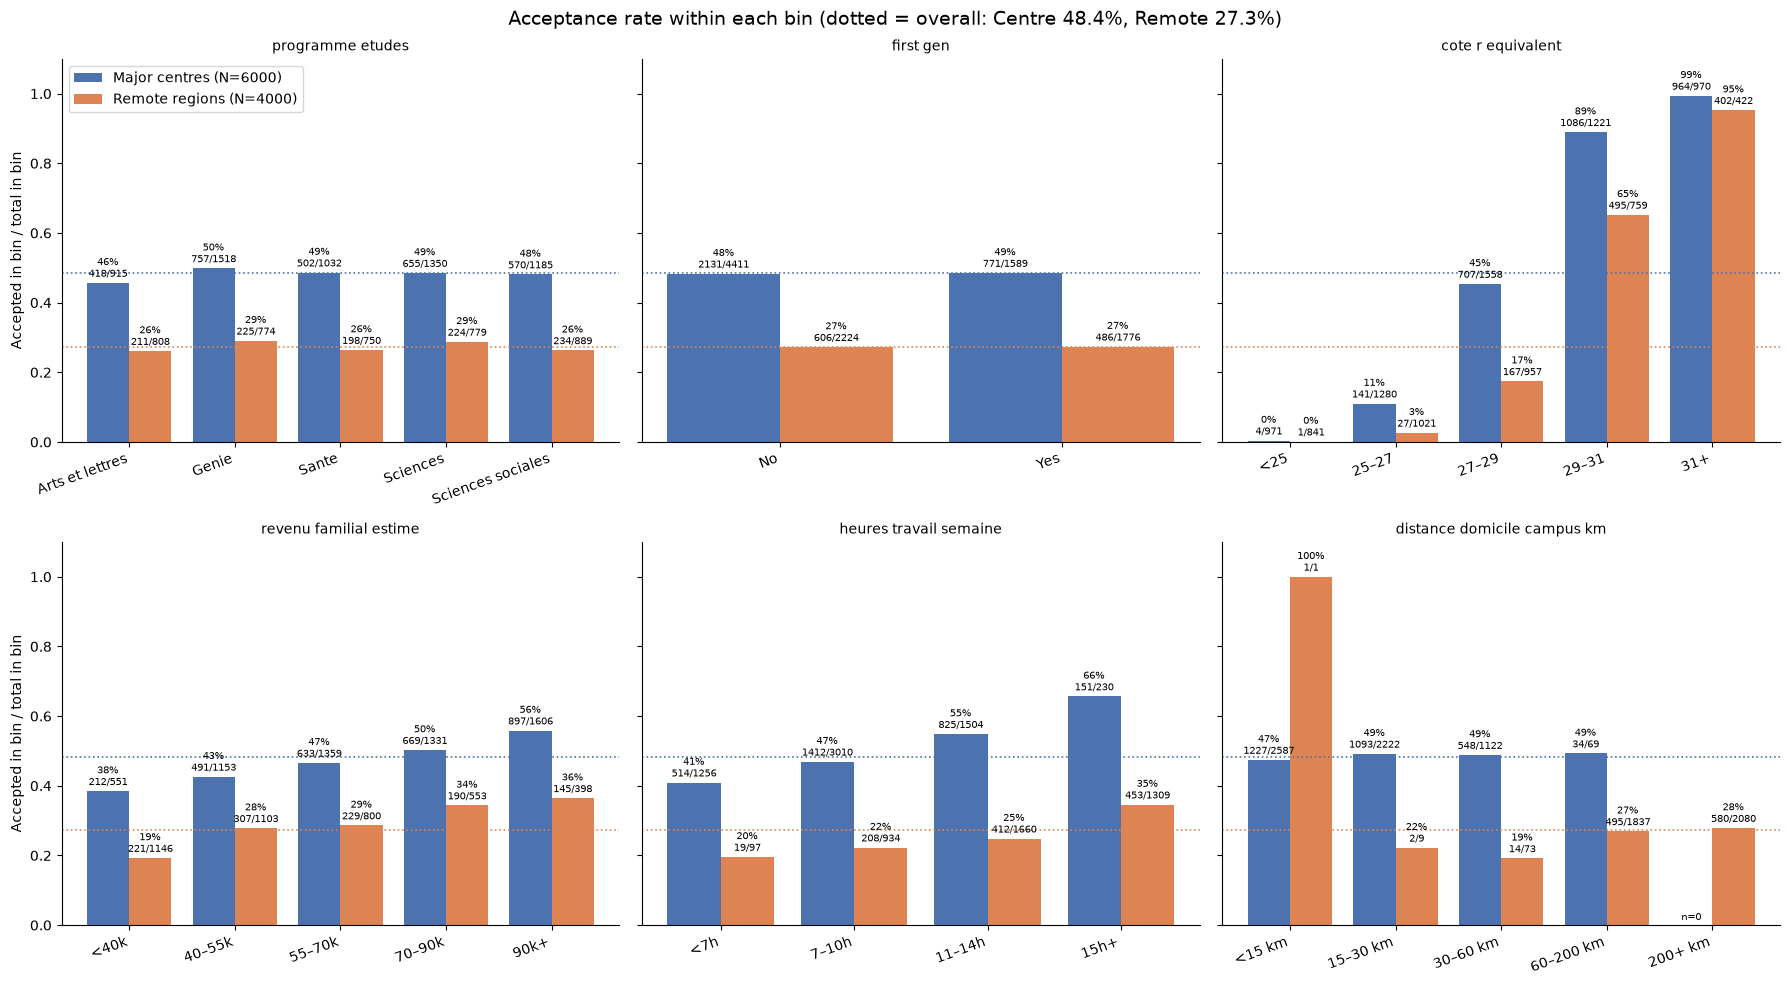

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df['groupe_region'] = groupe_region(df)
df['first_gen'] = df['premiere_generation_universitaire'].map({0: 'No', 1: 'Yes'})

groups = [('Centre', 'Major centres', '#4C72B0'), ('Eloignee', 'Remote regions', '#DD8452')]
features = ['programme_etudes', 'first_gen'] + [f'{c}_bucket' for c in buckets]
group_size = df['groupe_region'].value_counts()
overall = df.groupby('groupe_region')['decision_octroi'].mean()
width = 0.4

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

for ax, feat in zip(axes.flat, features):
    grp = df.groupby([feat, 'groupe_region'], observed=False)['decision_octroi']
    accepted = grp.sum().unstack().fillna(0)        # accepted in bin
    total = grp.count().unstack().fillna(0)         # everyone in bin
    rate = (accepted / total.replace(0, np.nan)).fillna(0)
    x = np.arange(len(rate))

    for i, (g, label, color) in enumerate(groups):
        bars = ax.bar(x + (i - 0.5) * width, rate[g], width, color=color,
                      label=f"{label} (N={group_size[g]})")
        ax.bar_label(bars, labels=[f"{v:.0%}\n{int(a)}/{int(n)}" if n > 0 else "n=0"
                                   for v, a, n in zip(rate[g], accepted[g], total[g])],
                     fontsize=7, padding=2)
        ax.axhline(overall[g], color=color, ls=':', lw=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(rate.index.astype(str), rotation=20, ha='right')
    ax.set_title(feat.replace('_bucket', '').replace('_', ' '), fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel("Accepted in bin / total in bin")
axes.flat[0].legend(loc='upper left')
fig.suptitle(f"Acceptance rate within each bin "
             f"(dotted = overall: Centre {overall['Centre']:.1%}, Remote {overall['Eloignee']:.1%})",
             fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

d = df.copy()
d["decision_octroi"] = d["decision_octroi"].astype(int)   # ensure 0/1
d["first_gen"] = d["first_gen"].str.lower().map({"yes": 1, "no": 0})

# Continuous features (not the _bucket versions), plus region.
# Excluded: id_candidat (ID), *_bucket (duplicate the continuous vars),
# premiere_generation_universitaire (same info as first_gen),
# code_postal_3 and groupe_region (derived from or nested in region, which causes collinearity).
formula = (
    "decision_octroi ~ cote_r_equivalent + revenu_familial_estime"
    " + heures_travail_semaine + distance_domicile_campus_km"
    " + first_gen + C(programme_etudes)"
    " + C(region_administrative)"
)

full = smf.logit(formula, data=d).fit(disp=0)
print(full.summary())

# Region coefficients: log-odds vs the reference region, plus odds ratios and 95% CIs
reg = full.params.filter(like="region_administrative")
ci = full.conf_int().loc[reg.index]
out = pd.DataFrame({
    "coef": reg,
    "OR": np.exp(reg),
    "OR_lo": np.exp(ci[0]),
    "OR_hi": np.exp(ci[1]),
    "p": full.pvalues[reg.index],
}).round(4)
print(out)

# Joint likelihood-ratio test: does region matter at all, given the other features?
reduced = smf.logit(formula.replace(" + C(region_administrative)", ""), data=d).fit(disp=0)
lr = 2 * (full.llf - reduced.llf)
dof = full.df_model - reduced.df_model
from scipy.stats import chi2
print(f"LR = {lr:.2f}, df = {int(dof)}, p = {chi2.sf(lr, dof):.4g}")

                           Logit Regression Results                           
Dep. Variable:        decision_octroi   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9986
Method:                           MLE   Df Model:                           13
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                  0.6137
Time:                        17:34:40   Log-Likelihood:                -2598.8
converged:                       True   LL-Null:                       -6727.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept                                                   -44.5786      0.978    -45.589      0.000     -46.495   